In [1]:
import sys
import os
from os.path import join, isfile, isdir
from glob import glob

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import ParameterGrid

from keras.models import load_model

sys.path.insert(0, "../code")
import abcsn_training_withSNR as at
import dataset_utils as du

from icecream import ic
plt.style.use("/home/2649/repos/foxstyle/custom.mplstyle")

2026-06-03 18:56:47.677767: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-03 18:56:47.695403: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-03 18:56:47.700976: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-03 18:56:47.715133: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-03 18:56:49.276092: W tensorflow/compiler/tf2

In [2]:
CVswap = False

In [3]:
# dir_project = "/lustre/lrspec/users/2649/SNRvsR"
# dir_data = join(dir_project, "datasets")
# dir_models = join(dir_project, "models")

# folder_snr_arr = [
#     # "SNR000.5",
#     # "SNR000.6",
#     # "SNR000.7",
#     # "SNR000.8",
#     # "SNR000.9",
#     "SNR001",
#     "SNR001.25",
#     "SNR001.5",
#     "SNR001.75",
#     "SNR002",
#     "SNR002.5",
#     "SNR005",
#     "SNR020",
#     "SNR025",
#     # "SNR050",
#     # "SNR100",
# ]
# folder_R_arr = [
#     # "R010",
#     # "R015",
#     # "R020",
#     "R025",
#     "R030",
#     "R035",
#     "R040",
#     "R045",
#     "R050",
#     "R100",
#     # "R200",
#     # "R300",
#     # "R400",
#     # "R500",
# ]

In [4]:
dir_project = "/lustre/lrspec/users/2649/SNRvsR"
dir_data = join(dir_project, "datasets")
dir_models = join(dir_project, "models")

folder_snr_arr = [
    "SNR000.5",
    "SNR000.6",
    "SNR000.7",
    "SNR000.8",
    "SNR000.9",
    "SNR001",
    "SNR001.25",
    "SNR001.5",
    "SNR001.75",
    "SNR002",
    "SNR002.5",
    "SNR005",
    "SNR020",
    "SNR025",
    "SNR050",
    "SNR100",
][::-1]
folder_R_arr = [
    "R010",
    "R015",
    "R020",
    "R025",
    "R030",
    "R035",
    "R040",
    "R045",
    "R050",
    "R100",
    "R200",
    "R300",
    "R400",
    "R500",
]

In [5]:
files = np.zeros((len(folder_snr_arr), len(folder_R_arr), 5), dtype=object)
metrics_arr = np.zeros((len(folder_snr_arr), len(folder_R_arr), 6), dtype=float)

In [6]:
cols = ['loss_trn', 'ca_trn', 'f1_trn', 'loss_tst', 'ca_tst', 'f1_tst', 'R', 'SNR']

In [7]:
folder_CV = ""
training_set = True
if CVswap:
    folder_CV = "CVswap"
    training_set = False

metrics_list = []
for i, folder_snr in enumerate(folder_snr_arr):
    for j, folder_R in enumerate(folder_R_arr):
        dir_output = join(dir_models, folder_snr, folder_R, folder_CV)
        file_metrics = join(dir_output, "ABCSN_metrics.csv")

        if not isdir(dir_output):
            metrics = pd.DataFrame(data=[[0, 0, 0, 0, 0, 0, folder_R, folder_snr]], columns=cols)
            metrics_list.append(metrics)
            continue

        if not isfile(file_metrics):
            metrics = pd.DataFrame(data=[[-1, -1, -1, -1, -1, -1, folder_R, folder_snr]], columns=cols)
            metrics_list.append(metrics)
        else:
            metrics = pd.read_csv(file_metrics)
            metrics["R"] = folder_R
            metrics["SNR"] = folder_snr

        metrics_arr[i, j, 0] = metrics.loc[0, "loss_trn"]
        metrics_arr[i, j, 1] = metrics.loc[0, "ca_trn"]
        metrics_arr[i, j, 2] = metrics.loc[0, "f1_trn"]
        metrics_arr[i, j, 3] = metrics.loc[0, "loss_tst"]
        metrics_arr[i, j, 4] = metrics.loc[0, "ca_tst"]
        metrics_arr[i, j, 5] = metrics.loc[0, "f1_tst"]
        metrics_list.append(metrics)
        

metrics_list = pd.concat(metrics_list, axis=0)
metrics_list

,loss_trn,ca_trn,f1_trn,loss_tst,ca_tst,f1_tst,R,SNR
0,2.320814,0.226026,0.142734,2.325311,0.086464,0.076043,R010,SNR100
0,0.641069,0.778811,0.774888,0.973632,0.732856,0.634265,R015,SNR100
0,0.407601,0.857910,0.855743,0.933190,0.791294,0.679078,R020,SNR100
0,0.331526,0.900117,0.898208,0.646020,0.849135,0.765603,R025,SNR100
0,0.211138,0.934935,0.934170,0.716039,0.844365,0.798185,R030,SNR100
...,...,...,...,...,...,...,...,...
0,0.451331,0.840368,0.839454,1.028849,0.680978,0.561745,R100,SNR000.5
0,0.539354,0.816660,0.815375,1.108834,0.673226,0.521534,R200,SNR000.5
0,0.426261,0.854720,0.853865,1.104821,0.673226,0.546005,R300,SNR000.5
0,0.552153,0.817297,0.814611,1.128972,0.650566,0.504680,R400,SNR000.5


In [8]:
# Set up xticks
xticks = np.arange(len(folder_R_arr))
xticklabels = [int(name[1:]) for name in folder_R_arr]
xticks, xticklabels

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 [10, 15, 20, 25, 30, 35, 40, 45, 50, 100, 200, 300, 400, 500])

In [9]:
# Set up yticks
yticks = np.arange(len(folder_snr_arr))
yticklabels = [float(name[3:]) for name in folder_snr_arr]
yticklabels = [int(name) if name == int(name) else name for name in yticklabels ]
yticks, yticklabels

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 [100, 50, 25, 20, 5, 2.5, 2, 1.75, 1.5, 1.25, 1, 0.9, 0.8, 0.7, 0.6, 0.5])

In [10]:
metric = 5

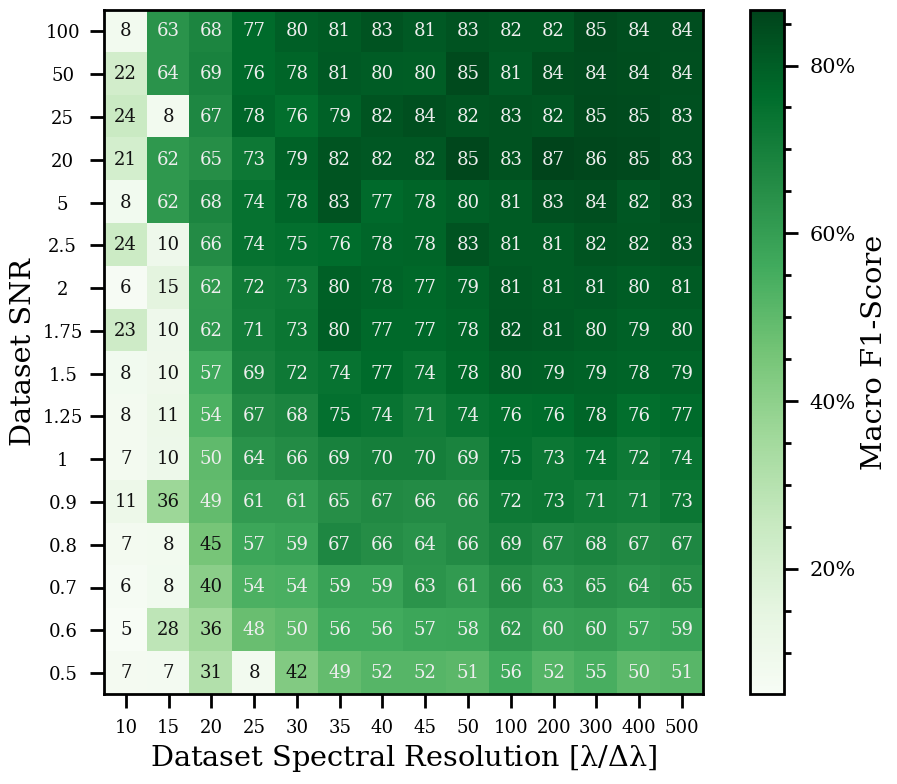

In [11]:
if metric == 0: cbar_label = "(Training Set) Loss"
elif metric == 1: cbar_label = "(Training Set) Accuracy"
elif metric == 2: cbar_label = "(Training Set) Macro F1-Score"
elif metric == 3: cbar_label = "Loss"
elif metric == 4: cbar_label = "Accuracy"
elif metric == 5: cbar_label = "Macro F1-Score"

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(metrics_arr[:, :, metric], vmin=None, vmax=None, interpolation=None, cmap="Greens")

ax.set_xticks(xticks, xticklabels)
ax.set_yticks(yticks, yticklabels)

ax.set_xlabel("Dataset Spectral Resolution [$\lambda / \Delta \lambda$]")
ax.set_ylabel("Dataset SNR")

cbar = plt.colorbar(mappable=im, ax=ax, label=cbar_label)

# cbar.set_ticks(
#     [0, .25, .5, .75, 1],
#     labels=["0%", "25%", "50%", "75%", "100%"])
cbar.set_ticks(
    [0.2, 0.4, 0.6, 0.8],
    labels=["20%", "40%", "60%", "80%"],
    size=15,
)

for i in range(metrics_arr.shape[0]):
    for j in range(metrics_arr.shape[1]):
        if metrics_arr[i, j, metric] <= 0:
            continue
        if metrics_arr[i, j, metric] >= np.mean(im.get_clim()):
            c = "#eeeeee"
        else:
            c = "#111111"
        ax.annotate(
            f"{metrics_arr[i, j, metric]*100:.0f}",
            (j, i),
            ha="center",
            va="center",
            c=c,
            size=13
        )

ax.tick_params(axis="both", which="both", direction="inout", bottom=False, top=False, left=False, right=False)
ax.tick_params(axis="both", which="major", direction="out", bottom=True, top=False, left=True, right=False)
ax.set_xticklabels(ax.get_xticklabels(), size=13)
ax.set_yticklabels(ax.get_yticklabels(), size=13, ha="center")
ax.tick_params(axis="y", pad=20)
fig.tight_layout()
fig.savefig("heatmap_full.pdf")
fig.savefig("heatmap_full.png")
fig.show()